In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.interpolate import interp1d
from scipy.odr import ODR, Model, RealData
from scipy.special import factorial
from scipy.integrate import quad
import re

In [9]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')  

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def linear(x, m, b):
        return m * x + b 

# Espessura e $\partial_x E$

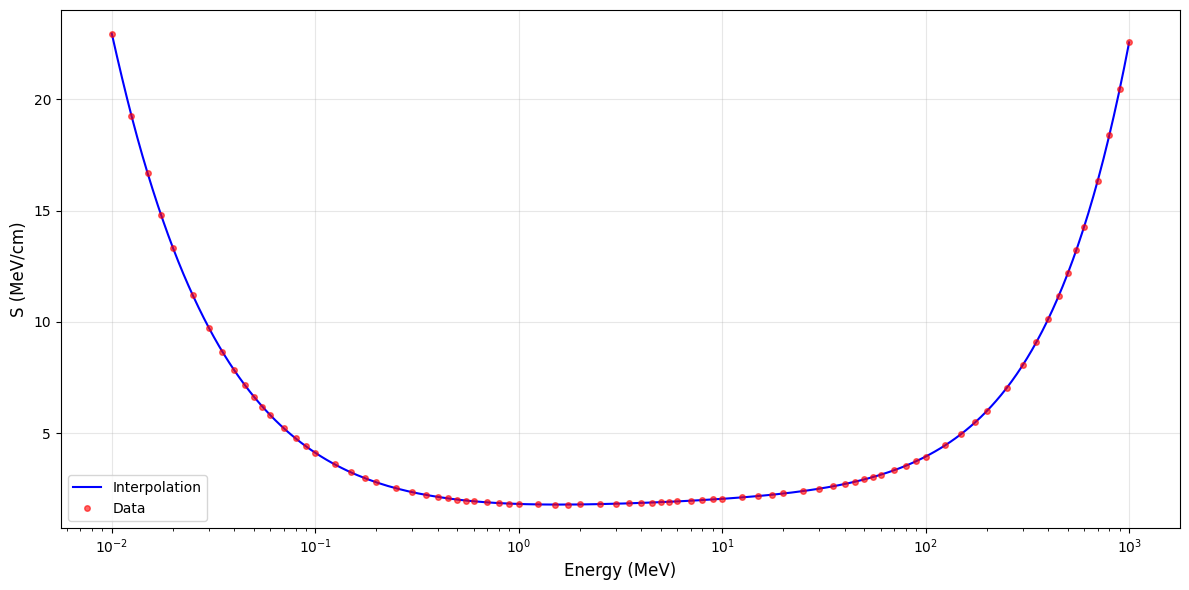

Δx = 0.050079 ± 0.002201 cm


In [10]:
rho = 9.40000e-01 #g/cm³

energy = np.array([
    1.000E-02, 1.250E-02, 1.500E-02, 1.750E-02, 2.000E-02, 2.500E-02, 
    3.000E-02, 3.500E-02, 4.000E-02, 4.500E-02, 5.000E-02, 5.500E-02, 
    6.000E-02, 7.000E-02, 8.000E-02, 9.000E-02, 1.000E-01, 1.250E-01, 
    1.500E-01, 1.750E-01, 2.000E-01, 2.500E-01, 3.000E-01, 3.500E-01, 
    4.000E-01, 4.500E-01, 5.000E-01, 5.500E-01, 6.000E-01, 7.000E-01, 
    8.000E-01, 9.000E-01, 1.000E+00, 1.250E+00, 1.500E+00, 1.750E+00, 
    2.000E+00, 2.500E+00, 3.000E+00, 3.500E+00, 4.000E+00, 4.500E+00, 
    5.000E+00, 5.500E+00, 6.000E+00, 7.000E+00, 8.000E+00, 9.000E+00, 
    1.000E+01, 1.250E+01, 1.500E+01, 1.750E+01, 2.000E+01, 2.500E+01, 
    3.000E+01, 3.500E+01, 4.000E+01, 4.500E+01, 5.000E+01, 5.500E+01, 
    6.000E+01, 7.000E+01, 8.000E+01, 9.000E+01, 1.000E+02, 1.250E+02, 
    1.500E+02, 1.750E+02, 2.000E+02, 2.500E+02, 3.000E+02, 3.500E+02, 
    4.000E+02, 4.500E+02, 5.000E+02, 5.500E+02, 6.000E+02, 7.000E+02, 
    8.000E+02, 9.000E+02, 1.000E+03
])

stopping_power = np.array([
    2.442E+01, 2.049E+01, 1.775E+01, 1.573E+01, 1.417E+01, 1.192E+01, 
    1.036E+01, 9.209E+00, 8.328E+00, 7.630E+00, 7.062E+00, 6.591E+00, 
    6.194E+00, 5.560E+00, 5.077E+00, 4.695E+00, 4.387E+00, 3.825E+00, 
    3.446E+00, 3.174E+00, 2.970E+00, 2.687E+00, 2.501E+00, 2.373E+00, 
    2.277E+00, 2.204E+00, 2.147E+00, 2.103E+00, 2.068E+00, 2.015E+00, 
    1.980E+00, 1.956E+00, 1.939E+00, 1.917E+00, 1.910E+00, 1.911E+00, 
    1.916E+00, 1.932E+00, 1.950E+00, 1.970E+00, 1.989E+00, 2.008E+00, 
    2.026E+00, 2.044E+00, 2.061E+00, 2.094E+00, 2.126E+00, 2.156E+00, 
    2.184E+00, 2.253E+00, 2.317E+00, 2.379E+00, 2.439E+00, 2.556E+00, 
    2.670E+00, 2.782E+00, 2.893E+00, 3.004E+00, 3.114E+00, 3.223E+00, 
    3.333E+00, 3.551E+00, 3.769E+00, 3.987E+00, 4.205E+00, 4.749E+00, 
    5.294E+00, 5.839E+00, 6.385E+00, 7.479E+00, 8.574E+00, 9.671E+00, 
    1.077E+01, 1.187E+01, 1.297E+01, 1.407E+01, 1.517E+01, 1.737E+01, 
    1.958E+01, 2.179E+01, 2.400E+01
])

S = stopping_power * rho

stopping_power_interp = interp1d(energy, S, kind='cubic', fill_value='extrapolate')

E_plot = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 200)
S_plot = stopping_power_interp(E_plot)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(E_plot, S_plot, 'b-', linewidth=1.5, label='Interpolation')
ax.plot(energy, S, 'ro', markersize=4, alpha=0.6, label='Data')
ax.set_xscale('log')
ax.set_xlabel('Energy (MeV)', fontsize=12)
ax.set_ylabel('S (MeV/cm)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def delta_x(E1, E2):
    integrand = lambda E: 1 / stopping_power_interp(E)
    result, error = quad(integrand, E1, E2)
    return result

def delta_x_with_error(E1, E2, sigma_E1, sigma_E2):
    dx = delta_x(E1, E2)
    
    # Error propagation: ∂Δx/∂E1 = -1/S(E1), ∂Δx/∂E2 = 1/S(E2)
    dS1 = stopping_power_interp(E1)
    dS2 = stopping_power_interp(E2)
    
    sigma_dx = np.sqrt((sigma_E1 / dS1)**2 + (sigma_E2 / dS2)**2)
    
    return dx, sigma_dx

# From 02_analise_espetros.ipynb
E1 = 0.7477  # Tl-204 covered
sigma_E1 = 0.0029
E2 = 0.8410  # Tl-204 uncovered
sigma_E2 = 0.0029

dx, sigma_dx = delta_x_with_error(E1, E2, sigma_E1, sigma_E2)

print(f"Δx = {dx:.6f} ± {sigma_dx:.6f} cm") 
